# Model Explainability and Cluster Integration

## Introduction

In Notebook 2, exploratory data analysis, principal component analysis (PCA), and K-Means clustering were used to identify meaningful patterns among countries based on demographic, healthcare, economic, and COVID-19-related characteristics. Those analyses provided insight into how countries naturally group together and highlighted differences in mortality across clusters.

This notebook shifts the focus from describing the data to explaining the predictions of the final machine learning model developed in Capstone 2. A tuned Random Forest regression model, previously identified as the best-performing model for predicting COVID-19 mortality, is examined using SHAP (SHapley Additive exPlanations). SHAP provides a consistent framework for interpreting complex machine learning models by quantifying how each feature contributes to individual predictions as well as overall model behavior.

The objectives of this notebook are to:

- Load the saved Random Forest model and associated preprocessing assets.
- Evaluate model predictions and identify representative countries based on prediction performance.
- Use SHAP to investigate global feature importance and the influence of individual predictors.
- Explain predictions for selected countries using local SHAP visualizations.
- Integrate the explainability results with the country clusters identified in Notebook 2 to determine whether the model relies on different factors across distinct groups of countries.
- Discuss the strengths and limitations of SHAP-based model interpretation in the context of country-level COVID-19 mortality prediction.

Together, the analyses in this notebook provide a deeper understanding of how the Random Forest model generates its predictions and complement the exploratory and clustering analyses presented in Notebook 2.

In [1]:
# ---------------------------------------
# Import Libraries
# ---------------------------------------

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import ipywidgets
import shap
import joblib

from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
# ---------------------------------------
# Configure Project Paths
# ---------------------------------------

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

assert (PROJECT_ROOT / "data").exists(), (
    "Project root not found."
)

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
INTERIM_DATA_DIR = DATA_DIR / "interim"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORT_DIR / "figures"
TABLE_DIR = REPORT_DIR / "tables"
MODEL_DIR = PROJECT_ROOT / "models"

NOTEBOOK_OUTPUT_DIR = PROJECT_ROOT / "notebook_outputs"

print(f"Project: {PROJECT_ROOT.name}")

# Source Project (Capstone 2)
SOURCE_PROJECT = PROJECT_ROOT.parent / "Capstone2"

SOURCE_MODEL_DIR = SOURCE_PROJECT / "models"
SOURCE_DATA_DIR = SOURCE_PROJECT / "data"
SOURCE_PROCESSED_DATA_DIR = SOURCE_DATA_DIR / "processed"

SOURCE_REPORT_DIR = SOURCE_PROJECT / "reports"
SOURCE_FIGURE_DIR = SOURCE_REPORT_DIR / "figures"
SOURCE_TABLE_DIR = SOURCE_REPORT_DIR / "tables"

print(f"Source Project: {SOURCE_PROJECT.name}")


Project: Capstone3
Source Project: Capstone2


In [3]:
# ---------------------------------------
# Load Saved Prediction Assets
# ---------------------------------------

model = joblib.load(
    SOURCE_MODEL_DIR / "random_forest_model.joblib"
)

scaler = joblib.load(
    SOURCE_MODEL_DIR / "standard_scaler.joblib"
)

feature_names = joblib.load(
    SOURCE_MODEL_DIR / "feature_names.joblib"
)

print("✓ Random Forest model and preprocessing assets loaded.")

✓ Random Forest model and preprocessing assets loaded.


In [4]:
# ---------------------------------------
# Load Prepared Capstone Three Datasets
# ---------------------------------------

# Load the reconstructed model dataset created in Notebook 1.
model_df = pd.read_csv(
    PROCESSED_DATA_DIR / "covid_model_dataset.csv"
)

print(
    f"Model dataset loaded: "
    f"{model_df.shape[0]:,} countries × "
    f"{model_df.shape[1]:,} variables"
)

# Load the final cluster assignments created in Notebook 2.
cluster_results_df = pd.read_csv(
    PROCESSED_DATA_DIR / "covid_cluster_assignments.csv"
)

print(
    f"Cluster assignments loaded: "
    f"{cluster_results_df.shape[0]:,} countries × "
    f"{cluster_results_df.shape[1]:,} variables"
)

Model dataset loaded: 239 countries × 12 variables
Cluster assignments loaded: 237 countries × 16 variables


In [5]:
# ---------------------------------------
# Load Saved Prediction Assets
# ---------------------------------------

# Load the trained Random Forest model.
rf_model = joblib.load(
    SOURCE_MODEL_DIR / "random_forest_model.joblib"
)

# Load the feature scaler used during model training.
scaler = joblib.load(
    SOURCE_MODEL_DIR / "standard_scaler.joblib"
)

# Load the training feature names in the correct order.
feature_names = joblib.load(
    SOURCE_MODEL_DIR / "feature_names.joblib"
)

print("Random Forest model loaded.")
print("Feature scaler loaded.")
print(f"{len(feature_names)} training features loaded.")

Random Forest model loaded.
Feature scaler loaded.
12 training features loaded.


In [6]:
# ---------------------------------------
# Display Labels
# ---------------------------------------

FEATURE_LABELS = {
    # Identifiers
    "country": "Country",
    "code": "Country Code",
    "continent": "Continent",

    # Outcome
    "total_deaths_per_million": "Deaths per Million",

    # Model Features
    "total_cases_per_million": "Cases per Million",
    "people_fully_vaccinated_per_hundred": "Fully Vaccinated (%)",
    "stringency_index": "Government Stringency Index",
    "median_age": "Median Age",
    "life_expectancy": "Life Expectancy (Years)",
    "hospital_beds_per_thousand": "Hospital Beds per 1,000",
    "gdp_per_capita": "GDP per Capita (USD)",

    # One-Hot Encoded Continents
    "continent_Asia": "Asia",
    "continent_Europe": "Europe",
    "continent_North America": "North America",
    "continent_Oceania": "Oceania",
    "continent_South America": "South America",
}

In [7]:
display_feature_names = [
    FEATURE_LABELS.get(feature, feature)
    for feature in feature_names
]

## Generate Predictions

This section applies the trained Random Forest model to the prepared modeling dataset and compares the predicted and observed COVID-19 mortality rates. These predictions provide the foundation for the residual analysis and SHAP-based model explanations presented in the following sections.

In [8]:
model_df = pd.read_csv(PROCESSED_DATA_DIR / "covid_model_dataset.csv")

model_input_df = pd.read_csv(
    PROCESSED_DATA_DIR / "covid_model_input_dataset.csv"
)

cluster_results_df = pd.read_csv(
    PROCESSED_DATA_DIR / "covid_cluster_assignments.csv"
)

print(f"Model dataset: {model_df.shape}")
print(f"Model input dataset: {model_input_df.shape}")
print(f"Cluster assignments: {cluster_results_df.shape}")

Model dataset: (239, 12)
Model input dataset: (239, 12)
Cluster assignments: (237, 16)


In [9]:
# ---------------------------------------
# Inspect Prepared Modeling Datasets
# ---------------------------------------

print("Model dataset:")
print(model_df.shape)
display(model_df.head())

print("\nModel input dataset:")
print(model_input_df.shape)
display(model_input_df.head())

Model dataset:
(239, 12)


,median_age,life_expectancy,total_cases_per_million,gdp_per_capita,hospital_beds_per_thousand,people_fully_vaccinated_per_hundred,stringency_index,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America
0,16.752001,65.616997,5796.4683,1983.812622,0.35,45.270844,27.394580,1.0,0.0,0.0,0.0,0.0
1,35.943001,78.768799,119264.5100,21641.074219,2.90,45.244260,41.782108,0.0,1.0,0.0,0.0,0.0
2,27.983000,76.128899,5990.6690,15501.919922,1.61,14.251447,48.367728,0.0,0.0,0.0,0.0,0.0
3,27.927000,72.752098,172831.6000,18068.505859,2.38,62.440320,43.273038,0.0,0.0,0.0,1.0,0.0
4,42.832001,84.016403,602280.4400,65928.304688,2.38,67.109460,33.486770,0.0,1.0,0.0,0.0,0.0



Model input dataset:
(239, 12)


,median_age,life_expectancy,total_cases_per_million,gdp_per_capita,hospital_beds_per_thousand,people_fully_vaccinated_per_hundred,stringency_index,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America
0,-1.499456,-1.003944,-0.995394,-1.001895,-1.077092,-0.560444,-1.935492,1.0,0.0,0.0,0.0,0.0
1,0.479201,0.672863,-0.452638,-0.190085,0.018526,-0.561612,-0.124120,0.0,1.0,0.0,0.0,0.0
2,-0.341502,0.336285,-0.994465,-0.443621,-0.535728,-1.922869,0.705002,0.0,0.0,0.0,0.0,0.0
3,-0.347276,-0.094245,-0.196408,-0.337626,-0.204894,0.193669,0.063586,0.0,0.0,0.0,1.0,0.0
4,1.189481,1.341914,1.857793,1.638899,-0.204894,0.398745,-1.168492,0.0,1.0,0.0,0.0,0.0


In [10]:
# ---------------------------------------
# Generate Model Predictions
# ---------------------------------------

# Generate predictions using the trained Random Forest model.
predictions = rf_model.predict(model_input_df)

print(f"Generated predictions for {len(predictions):,} countries.")

Generated predictions for 239 countries.


In [11]:
# ---------------------------------------
# Load Country Identifiers and Outcomes
# ---------------------------------------

analysis_df = pd.read_csv(
    SOURCE_PROCESSED_DATA_DIR / "covid_analysis_dataset.csv"
)

print(
    f"Analytical dataset loaded: "
    f"{analysis_df.shape[0]:,} countries × "
    f"{analysis_df.shape[1]:,} variables"
)

Analytical dataset loaded: 239 countries × 22 variables


In [12]:
# ---------------------------------------
# Assemble Prediction Results
# ---------------------------------------

prediction_results_df = analysis_df[
    [
        "country",
        "continent",
        "total_deaths_per_million",
    ]
].copy()

prediction_results_df["predicted_deaths_per_million"] = predictions

prediction_results_df["residual"] = (
    prediction_results_df["total_deaths_per_million"]
    - prediction_results_df["predicted_deaths_per_million"]
)

print(f"Prediction results: {prediction_results_df.shape}")
display(prediction_results_df.head())

Prediction results: (239, 5)


,country,continent,total_deaths_per_million,predicted_deaths_per_million,residual
0,Afghanistan,Asia,197.09776,106.520683,90.577077
1,Albania,Europe,1275.98740,1602.220766,-326.233366
2,Algeria,Africa,151.30595,303.154977,-151.849027
3,American Samoa,Oceania,702.98770,761.575014,-58.587314
4,Andorra,Europe,1994.43070,1903.709640,90.721060


## Global SHAP Analysis

SHAP (SHapley Additive exPlanations) explains the contribution of each feature to every prediction made by the Random Forest model. This section examines feature importance across all countries to identify the variables that most strongly influence predicted COVID-19 mortality.

In [13]:
# ---------------------------------------
# Create SHAP Explainer
# ---------------------------------------

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(model_input_df)

print(f"SHAP values calculated for {len(model_input_df):,} countries.")
print(f"SHAP values shape: {shap_values.shape}")

SHAP values calculated for 239 countries.
SHAP values shape: (239, 12)


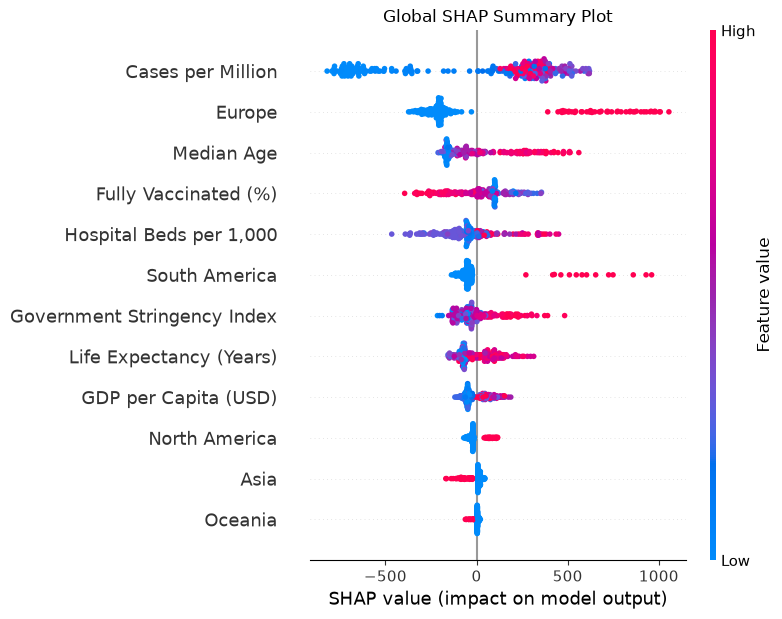

In [14]:
# ---------------------------------------
# Figure 7. Global SHAP Summary Plot
# ---------------------------------------

shap.summary_plot(
    shap_values,
    model_input_df,
    feature_names=display_feature_names,
    show=False,
)

plt.title("Global SHAP Summary Plot")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "Figure7_Global_SHAP_Summary.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Global SHAP Feature Importance

The SHAP feature-importance plot ranks predictors by their mean absolute SHAP value across all countries. Unlike the summary plot, which also shows the direction and distribution of feature effects, this plot provides a concise comparison of each predictor's overall influence on the model.

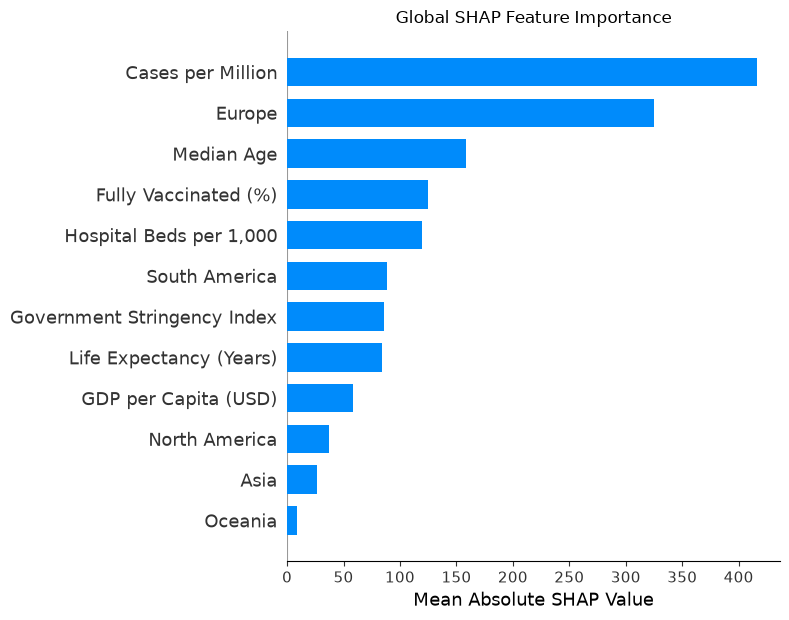

In [15]:
# ---------------------------------------
# Figure 8. Global SHAP Feature Importance
# ---------------------------------------

shap.summary_plot(
    shap_values,
    model_input_df,
    feature_names=display_feature_names,
    plot_type="bar",
    show=False,
)

plt.title("Global SHAP Feature Importance")
plt.xlabel("Mean Absolute SHAP Value")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "Figure8_Global_SHAP_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

**Interpretation**

Cases per Million was the most influential predictor of the Random Forest model's mortality predictions, followed by European location and Median Age. Vaccination coverage and Hospital Beds per 1,000 also made substantial contributions. The remaining predictors had smaller average effects, although some may still be important for particular countries. Because this plot uses mean absolute SHAP values, it measures the overall magnitude of each feature's influence without indicating whether the feature increased or decreased predicted mortality.

## SHAP Dependence Plots

While the previous figures summarize overall feature importance, SHAP dependence plots illustrate how individual feature values influence model predictions across countries. The following plots focus on the most influential predictors identified in the global SHAP analysis.

In [16]:
# ---------------------------------------
# SHAP Dependence Plot Features
# ---------------------------------------

top_features = [
    "total_cases_per_million",
    "median_age",
    "people_fully_vaccinated_per_hundred",
    "hospital_beds_per_thousand",
    "stringency_index",
    "life_expectancy",
]

print("Dependence plots will be created for:")
for feature in top_features:
    print(f"  • {FEATURE_LABELS[feature]}")

Dependence plots will be created for:
  • Cases per Million
  • Median Age
  • Fully Vaccinated (%)
  • Hospital Beds per 1,000
  • Government Stringency Index
  • Life Expectancy (Years)


In [17]:
covid_worldbank_check = pd.read_csv(
    SOURCE_PROCESSED_DATA_DIR / "covid_analysis_dataset.csv"
)

print(covid_worldbank_check.shape)

# Number of missing hospital bed values
print(
    covid_worldbank_check["hospital_beds_per_thousand"]
    .isna()
    .sum()
)

# Quick summary
#covid_worldbank_check["hospital_beds_per_thousand"].describe()
covid_worldbank_check[top_features].isna().sum()

(239, 22)
71


total_cases_per_million                 6
median_age                              2
people_fully_vaccinated_per_hundred    24
hospital_beds_per_thousand             71
stringency_index                       54
life_expectancy                         2
dtype: int64

In [18]:
# ---------------------------------------
# Create Imputation Flags
# ---------------------------------------

imputation_flags = (
    covid_worldbank_check[top_features]
    .isna()
    .add_suffix("_imputed")
)

assert model_df.index.equals(imputation_flags.index)

# Verify the flag counts
imputation_flags.sum()


total_cases_per_million_imputed                 6
median_age_imputed                              2
people_fully_vaccinated_per_hundred_imputed    24
hospital_beds_per_thousand_imputed             71
stringency_index_imputed                       54
life_expectancy_imputed                         2
dtype: int64

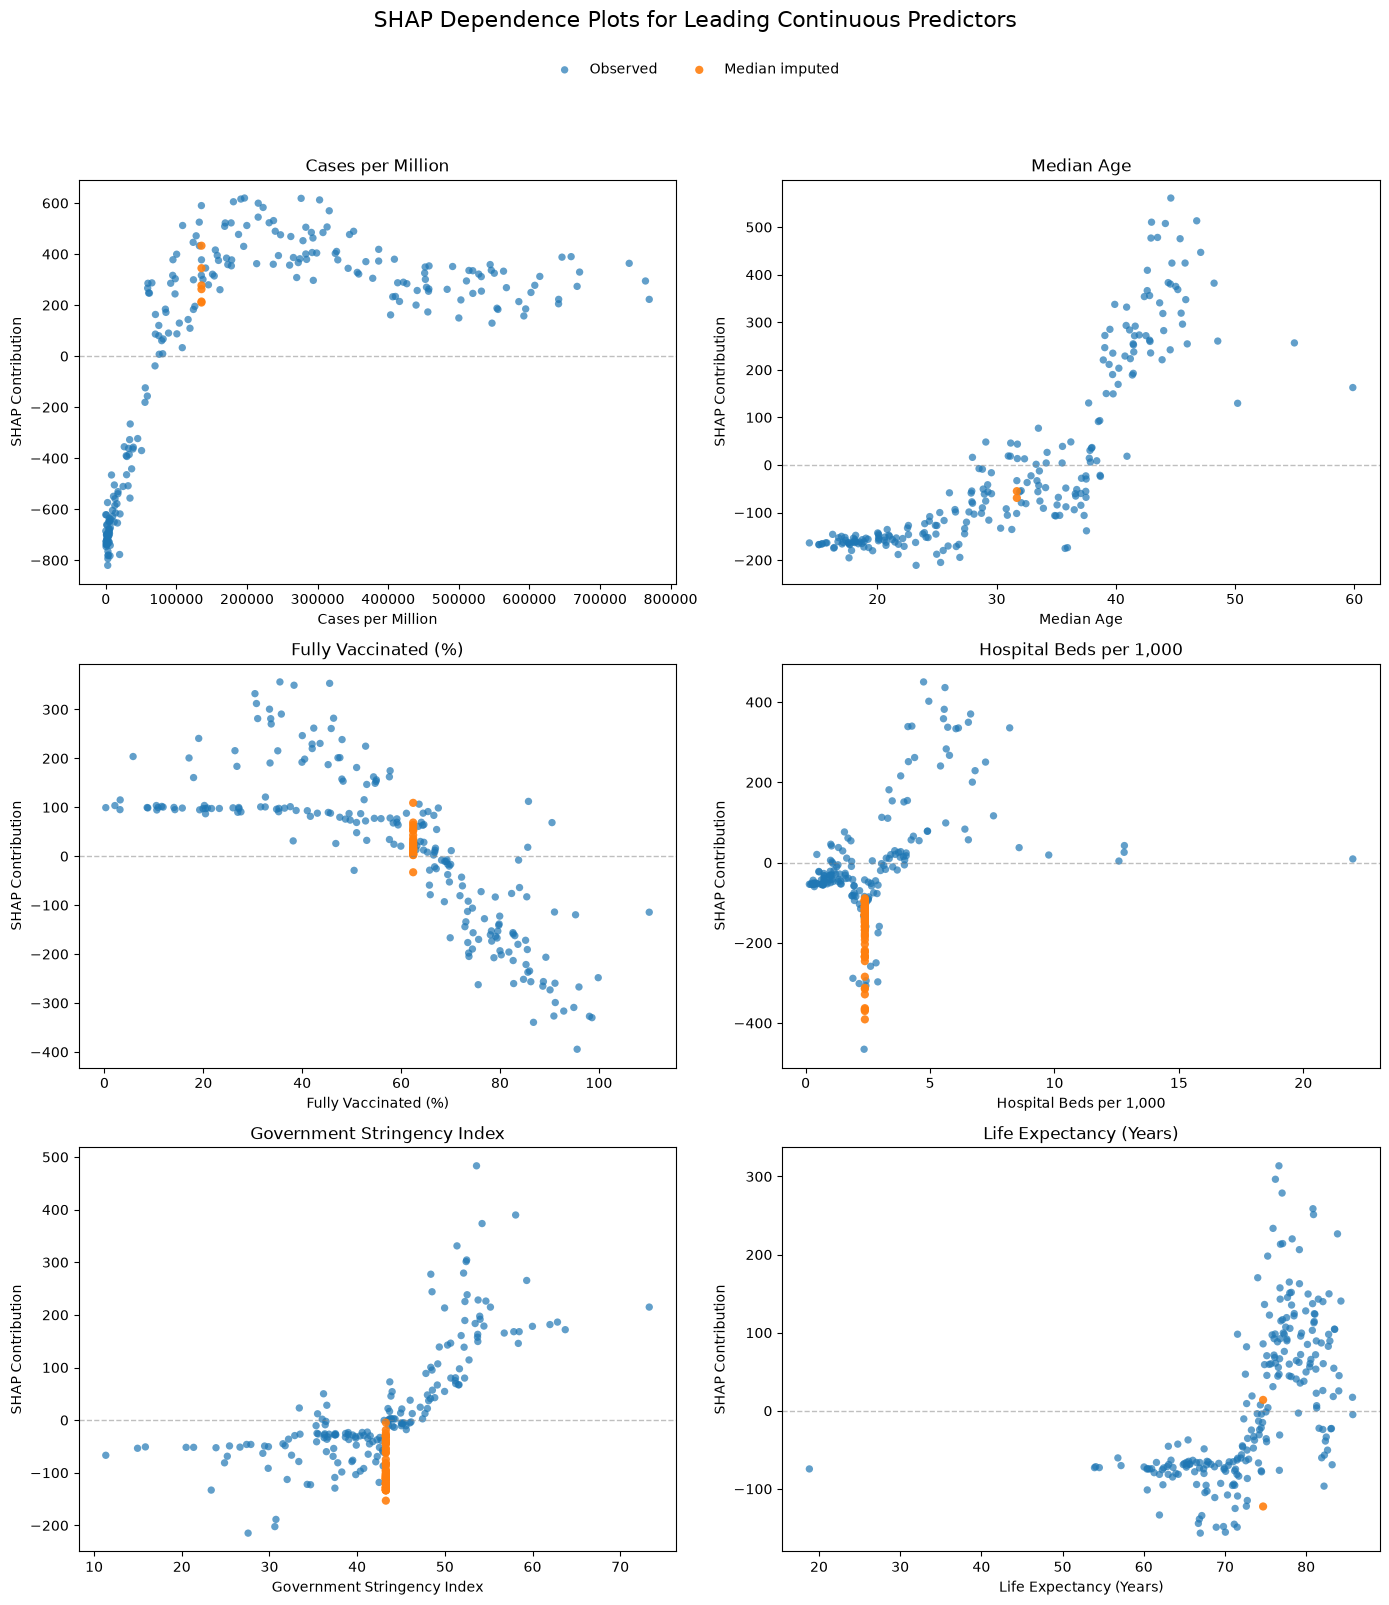

In [19]:
# ---------------------------------------
# Figure 9. SHAP Dependence Plots
# ---------------------------------------

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 16),
)

axes = axes.flatten()

for ax, feature in zip(axes, top_features):

    feature_index = feature_names.index(feature)
    imputed = imputation_flags[f"{feature}_imputed"]

    # Observed values
    ax.scatter(
        model_df.loc[~imputed, feature],
        shap_values[~imputed, feature_index],
        s=28,
        alpha=0.7,
        edgecolors="none",
        label="Observed",
    )

    # Median-imputed values
    ax.scatter(
        model_df.loc[imputed, feature],
        shap_values[imputed, feature_index],
        s=35,
        alpha=0.9,
        edgecolors="none",
        label="Median imputed",
    )

    ax.axhline(
        0,
        color="gray",
        linestyle="--",
        linewidth=1,
        alpha=0.5,
    )

    ax.set_title(FEATURE_LABELS[feature])
    ax.set_xlabel(FEATURE_LABELS[feature])
    ax.set_ylabel("SHAP Contribution")

# Use the legend entries from the first subplot
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.975),
    ncol=2,
    frameon=False,
)

fig.suptitle(
    "SHAP Dependence Plots for Leading Continuous Predictors",
    fontsize=16,
    y=1.0,
)

# Leave room at the top for the title and shared legend
plt.tight_layout(rect=[0, 0, 1, 0.94])

plt.savefig(
    FIGURE_DIR / "Figure9_SHAP_Dependence_Plots.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Interpretation

The SHAP dependence plots show how each of the six leading continuous predictors contributed to the Random Forest mortality predictions across countries. Each point represents one country. The x-axis shows the predictor value used by the model, and the y-axis shows that feature's SHAP contribution. Positive SHAP contributions increase the predicted mortality, while negative contributions decrease it. Blue points represent observed predictor values, whereas orange points represent values that were missing and replaced through median imputation.

Cases per Million exhibited the strongest overall relationship with predicted mortality. Countries with low case rates generally had strongly negative SHAP contributions, while increasing case rates were associated with rapidly increasing contributions. At the highest case rates, the relationship began to level off, indicating a nonlinear pattern with diminishing additional influence. Only a small number of case-rate observations were imputed, so the overall pattern is driven primarily by observed data.

Median Age showed a generally increasing relationship with predicted mortality. Younger populations contributed negatively to mortality predictions, while older populations increasingly raised the predicted outcome. Because only two median-age values were imputed, this relationship is also based almost entirely on observed values.

Fully Vaccinated (%) demonstrated a strong inverse relationship with predicted mortality. Higher vaccination coverage was associated with increasingly negative SHAP contributions, indicating that greater vaccination coverage reduced the model's mortality predictions. The vertical orange band near the median reflects countries whose vaccination values were missing and median-imputed. These countries share the same modeled vaccination value but receive different SHAP contributions because the Random Forest evaluates vaccination in combination with the other predictors.

Hospital Beds per 1,000 showed substantial variation in SHAP contributions. The prominent vertical orange band near the median hospital-bed value represents the 71 countries whose missing values were median-imputed. The wide range of contributions among these countries demonstrates that the model did not assign a single fixed effect to the imputed value. Instead, the contribution of hospital-bed availability depended on each country's broader demographic, epidemiologic, and healthcare profile. Because a large portion of this feature was imputed, its dependence plot should be interpreted more cautiously than those based primarily on observed values.

Government Stringency Index also contained substantial imputation, with 54 countries receiving the median value. The plot showed a nonlinear relationship in which lower stringency values generally had small or negative contributions, while higher values were associated with more positive contributions. This pattern should not be interpreted as evidence that stricter policies caused higher mortality. More likely, countries experiencing severe outbreaks implemented stronger public-health restrictions, making stringency partly a marker of outbreak severity. The concentration of imputed observations at the median further limits causal interpretation of this feature.

Life Expectancy generally showed increasing SHAP contributions at higher values, with countries having longer life expectancy tending to receive higher mortality predictions. This may partly reflect the relationship between life expectancy and older population structures. Only two life-expectancy observations were imputed, so this pattern is almost entirely supported by observed data.

Across all six plots, countries with similar predictor values often received different SHAP contributions. This vertical spread reflects interactions within the Random Forest: the effect attributed to one predictor depends on the country's other characteristics. The imputation coloring adds an important diagnostic layer by showing where apparent vertical concentrations arise from preprocessing rather than from naturally repeated observed values.

## Local SHAP Explanations

While the global SHAP analyses identified the predictors that generally influenced mortality predictions across all countries, they do not explain why the model produced a particular prediction for an individual country. Local SHAP explanations address this question by decomposing a single prediction into the contributions of each predictor relative to the model's baseline prediction.

To illustrate how the Random Forest combines multiple risk factors, three representative countries were selected for detailed examination:

- The country with the highest predicted mortality.
- The country with the lowest predicted mortality.
- A country whose predicted mortality was closest to the average prediction for its assigned cluster.

The first two examples demonstrate the characteristics associated with the most extreme model predictions, while the third illustrates how the model explains a country that is representative of other countries with similar demographic, healthcare, and epidemiologic profiles. Together, these examples provide a more intuitive understanding of how individual predictors combine to produce country-specific mortality estimates.

In [20]:
# ---------------------------------------
# Create Country SHAP Summary
# ---------------------------------------

country_shap_summary = (
    prediction_results_df
    .merge(
        cluster_results_df[["country", "Cluster"]],
        on="country",
        how="left",
        validate="one_to_one",
    )
    .rename(
        columns={
            "country": "Country",
            "total_deaths_per_million": "Actual Mortality",
            "predicted_deaths_per_million": "Predicted Mortality",
            "residual": "Residual",
        }
    )
)

# TreeSHAP baseline
shap_baseline = float(
    np.asarray(explainer.expected_value).squeeze()
)

country_shap_summary["SHAP Baseline"] = shap_baseline

country_shap_summary["Distance from Baseline"] = (
    country_shap_summary["Predicted Mortality"]
    - country_shap_summary["SHAP Baseline"]
)

# Mean predicted mortality within each cluster
country_shap_summary["Cluster Mean Prediction"] = (
    country_shap_summary
    .groupby("Cluster")["Predicted Mortality"]
    .transform("mean")
)

country_shap_summary["Distance from Cluster Mean"] = (
    country_shap_summary["Predicted Mortality"]
    - country_shap_summary["Cluster Mean Prediction"]
)

country_shap_summary.head()

,Country,continent,Actual Mortality,Predicted Mortality,Residual,Cluster,SHAP Baseline,Distance from Baseline,Cluster Mean Prediction,Distance from Cluster Mean
0,Afghanistan,Asia,197.09776,106.520683,90.577077,0.0,1309.023298,-1202.502615,237.636681,-131.115998
1,Albania,Europe,1275.98740,1602.220766,-326.233366,3.0,1309.023298,293.197468,1111.036162,491.184603
2,Algeria,Africa,151.30595,303.154977,-151.849027,3.0,1309.023298,-1005.868321,1111.036162,-807.881186
3,American Samoa,Oceania,702.98770,761.575014,-58.587314,3.0,1309.023298,-547.448284,1111.036162,-349.461148
4,Andorra,Europe,1994.43070,1903.709640,90.721060,1.0,1309.023298,594.686343,2200.579744,-296.870104


In [21]:
# ---------------------------------------
# Select Representative Countries
# ---------------------------------------

highest_country = country_shap_summary.loc[
    country_shap_summary["Predicted Mortality"].idxmax()
]

lowest_country = country_shap_summary.loc[
    country_shap_summary["Predicted Mortality"].idxmin()
]

clustered_countries = country_shap_summary.dropna(
    subset=["Cluster Mean Prediction"]
)

representative_country = clustered_countries.loc[
    clustered_countries[
        "Distance from Cluster Mean"
    ].abs().idxmin()
]

selected_countries = pd.DataFrame(
    [
        highest_country,
        lowest_country,
        representative_country,
    ],
    index=[
        "Highest Prediction",
        "Lowest Prediction",
        "Closest to Cluster Mean",
    ],
)

selected_countries[
    [
        "Country",
        "Actual Mortality",
        "Predicted Mortality",
        "Cluster",
        "Cluster Mean Prediction",
        "Distance from Cluster Mean",
    ]
]

,Country,Actual Mortality,Predicted Mortality,Cluster,Cluster Mean Prediction,Distance from Cluster Mean
Highest Prediction,North Macedonia,5429.195000,4509.815484,1.0,2200.579744,2309.235740
Lowest Prediction,Sierra Leone,15.223258,17.676823,0.0,237.636681,-219.959858
Closest to Cluster Mean,Hong Kong,NaN,1474.968485,2.0,1469.451240,5.517245


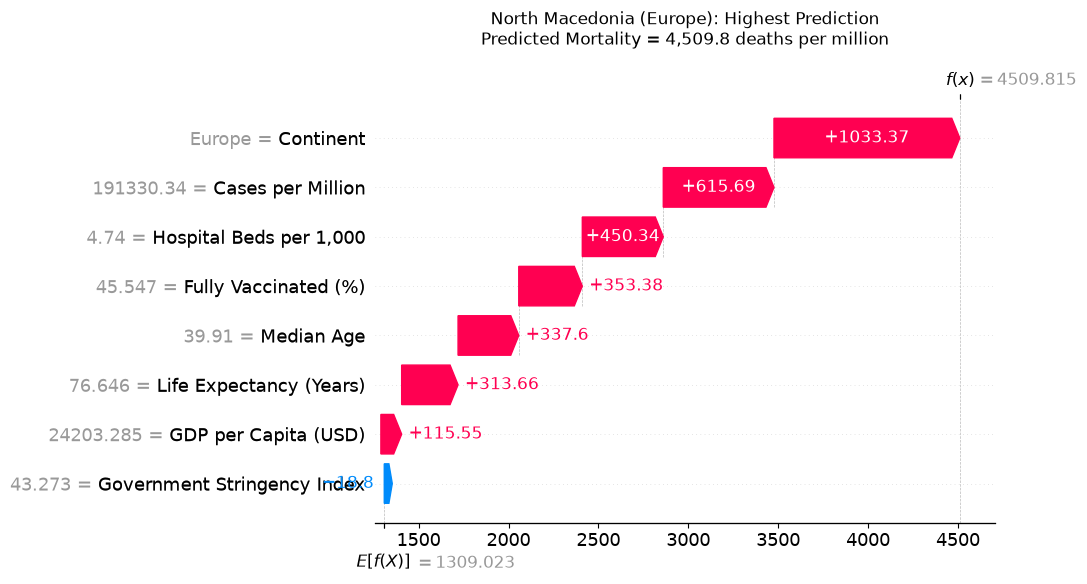

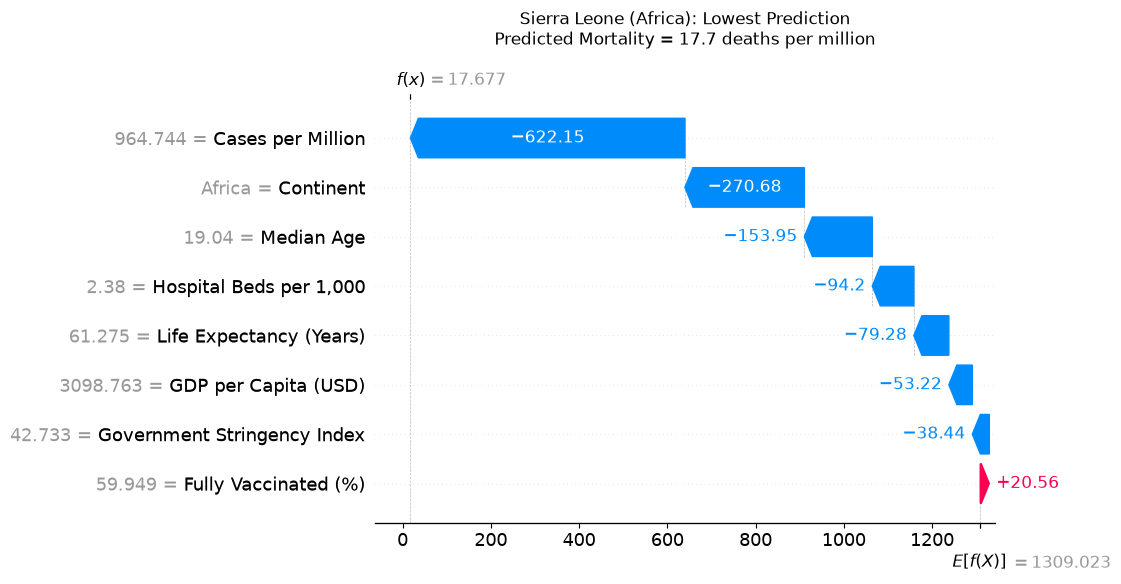

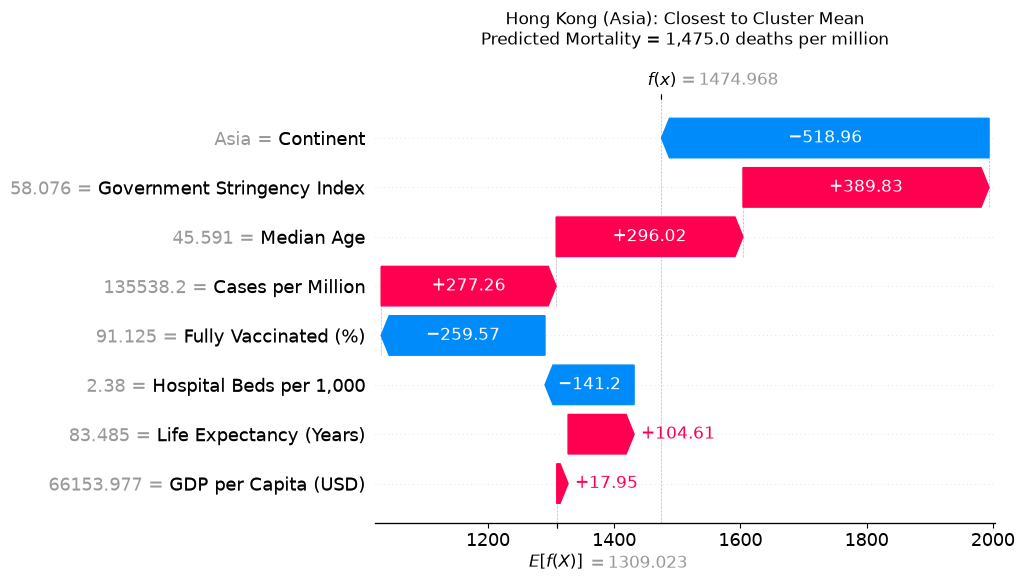

In [22]:
# ---------------------------------------
# Figure 10. Local SHAP Waterfall Plots
# ---------------------------------------

selected_country_names = [
    highest_country["Country"],
    lowest_country["Country"],
    representative_country["Country"],
]

selection_labels = [
    "Highest Prediction",
    "Lowest Prediction",
    "Closest to Cluster Mean",
]

# Identify the one-hot encoded continent features
continent_indices = [
    i
    for i, feature in enumerate(feature_names)
    if feature.startswith("continent_")
]

# Retain all non-continent features
non_continent_indices = [
    i
    for i in range(len(feature_names))
    if i not in continent_indices
]

for figure_number, (country, selection_label) in enumerate(
    zip(selected_country_names, selection_labels),
    start=10,
):
    # Locate the country in the prediction/modeling data
    country_index = prediction_results_df.index[
        prediction_results_df["country"].eq(country)
    ][0]

    # Retrieve the country's continent
    continent = prediction_results_df.loc[country_index, "continent"]

    # SHAP values for the individual country
    country_shap_values = np.asarray(shap_values[country_index])

    # Sum the SHAP contributions from all continent dummy variables
    continent_shap_value = country_shap_values[
        continent_indices
    ].sum()

    # Retain the original numeric feature values
    combined_data = list(
        model_df.iloc[country_index].values[
            non_continent_indices
        ]
    )

    # Add the actual continent as the displayed feature value
    combined_data.append(continent)


    #combined_data.append("")
#combined_feature_names.append(f"Continent: {continent}")

    # Retain the non-continent SHAP values and add the combined continent value
    combined_shap_values = list(
        country_shap_values[non_continent_indices]
    )
    combined_shap_values.append(continent_shap_value)

    # Retain the non-continent display names and add one continent row
    combined_feature_names = [
        display_feature_names[i]
        for i in non_continent_indices
    ]
    combined_feature_names.append("Continent")

    # Build the grouped local SHAP explanation
    country_explanation = shap.Explanation(
        values=np.asarray(combined_shap_values),
        base_values=shap_baseline,
        data=np.asarray(combined_data, dtype=object),
        feature_names=combined_feature_names,
    )

    shap.plots.waterfall(
        country_explanation,
        max_display=len(combined_feature_names),
        show=False,
    )

    plt.title(
        f"{country} ({continent}): {selection_label}\n"
        f"Predicted Mortality = "
        f"{prediction_results_df.loc[country_index, 'predicted_deaths_per_million']:,.1f} "
        f"deaths per million",
        pad=20,
    )

    plt.savefig(
        FIGURE_DIR
        / f"Figure{figure_number}_{country.replace(' ', '_')}_SHAP_Waterfall.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

### Interpretation

The local SHAP explanations provide insight into how the Random Forest combined individual predictors to produce country-specific mortality predictions. Unlike the global SHAP analyses, which describe average predictor importance across all countries, these waterfall plots explain the factors contributing to a single prediction by showing how each feature moves the estimate away from the model's baseline prediction.

North Macedonia represents the highest predicted mortality in the dataset. Nearly all of the major predictors pushed the prediction upward relative to the baseline, including a very high case rate, European location, greater hospital-bed availability, older population, higher life expectancy, and moderate vaccination coverage. Rather than being driven by a single dominant predictor, the extremely high prediction resulted from multiple risk factors acting in the same direction, illustrating how the Random Forest combines information across many features.

In contrast, Sierra Leone received the lowest predicted mortality. Nearly every major predictor reduced the prediction below the model baseline, with the country's very low case rate providing the largest negative contribution. A younger population, lower life expectancy, lower economic development, and lower government stringency further reduced the predicted mortality. This example demonstrates how the absence of several high-risk characteristics can collectively produce an exceptionally low prediction.

Hong Kong was selected because its predicted mortality was closest to the average prediction for its assigned cluster, making it representative of countries with similar overall characteristics. Unlike the previous two examples, the prediction resulted from a balance of opposing influences rather than uniformly positive or negative contributions. Older population characteristics, higher case rates, and stronger government stringency increased the prediction, while high vaccination coverage and other factors reduced it. The resulting prediction closely matched the cluster average, illustrating that representative countries may still exhibit substantial positive and negative feature contributions that offset one another.

Together, these examples demonstrate that the Random Forest predictions arise from the combined influence of multiple interacting predictors rather than any single variable. Countries with the highest predicted mortality typically accumulated several positive risk contributions, countries with the lowest predicted mortality accumulated several protective contributions, and countries representative of their cluster reflected a balance between opposing influences. These local explanations complement the global SHAP analyses by revealing how the model applies the learned relationships to individual countries.

Distance from Cluster Mean

## Countries Relative to Their Cluster

The previous SHAP analyses explained how the Random Forest model generated mortality predictions and identified the factors that contributed to individual country predictions. A complementary question is whether a country's predicted mortality is unusually high or low compared with countries that share similar demographic, healthcare, and epidemiologic characteristics.

To address this question, each country's predicted mortality was compared with the average predicted mortality of its assigned cluster. Because countries within a cluster share similar underlying characteristics, this comparison provides a measure of how exceptional a country's prediction is relative to its peers rather than relative to all countries worldwide.

Positive values indicate countries whose predicted mortality exceeds the average for similar countries, whereas negative values indicate countries with lower predicted mortality than expected for their cluster. This perspective complements the global SHAP analyses by highlighting countries whose overall risk profiles differ substantially from other members of their cluster.

In [23]:
# ---------------------------------------
# Table X. Cluster Prediction Summary
# ---------------------------------------

cluster_summary = (
    country_shap_summary
    .groupby("Cluster")
    .agg(
        Countries=("Country", "count"),
        Mean_Predicted_Mortality=("Predicted Mortality", "mean"),
        Mean_Actual_Mortality=("Actual Mortality", "mean"),
        Std_Dev=("Predicted Mortality", "std"),
    )
    .round(1)
)

cluster_summary

,Countries,Mean_Predicted_Mortality,Mean_Actual_Mortality,Std_Dev
Cluster,,,,
0.0,54,237.6,217.3,403.1
1.0,77,2200.6,2279.8,1078.2
2.0,3,1469.5,1680.5,718.9
3.0,103,1111.0,1064.6,763.4


In [24]:
import plotly.express as px

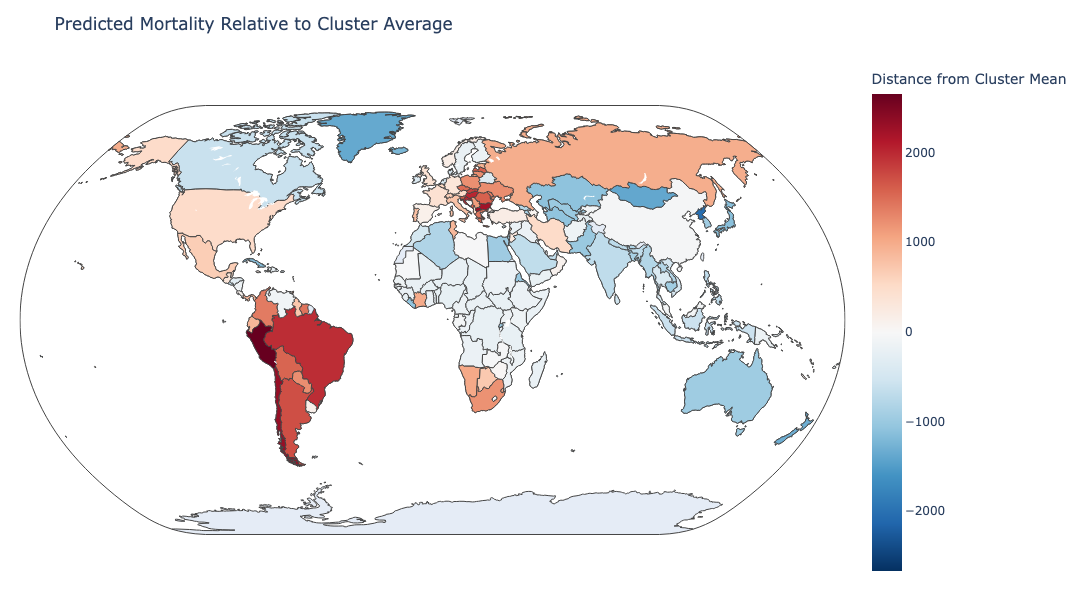

In [25]:
# ---------------------------------------
# Figure X. Predicted Mortality Relative
# to Cluster Average
# ---------------------------------------

import plotly.express as px

# Add ISO codes to the summary table
country_shap_summary = (
    country_shap_summary
    .merge(
        analysis_df[["country", "iso_code"]],
        left_on="Country",
        right_on="country",
        how="left"
    )
    .drop(columns="country")
)

fig = px.choropleth(
    country_shap_summary,
    locations="iso_code",
    color="Distance from Cluster Mean",
    hover_name="Country",
    hover_data={
        "Predicted Mortality": ":.0f",
        "Actual Mortality": ":.0f",
        "Cluster": True,
        "Distance from Cluster Mean": ":.0f",
        "iso_code": False,
    },
    color_continuous_scale="RdBu_r",
    color_continuous_midpoint=0,
    projection="natural earth",
    title="Predicted Mortality Relative to Cluster Average",
)

fig.update_layout(
    width=1100,
    height=600,
    margin=dict(l=20, r=20, t=60, b=20),
)

fig.show()

### Interpretation

Comparing predicted mortality with the average prediction for each cluster reveals regional patterns that are not immediately apparent from the global SHAP analyses. Countries in South America—including Peru, Chile, Brazil, Argentina, and Bolivia—consistently exhibit predicted mortality well above the average for countries with otherwise similar demographic, healthcare, and epidemiologic characteristics. A similar pattern is observed across several Eastern European and Balkan countries, including North Macedonia, Bulgaria, Croatia, Hungary, and Slovakia.

In contrast, many countries in East Asia and Oceania—including Taiwan, Japan, South Korea, Australia, and New Zealand—display predicted mortality well below the average for their respective clusters. These findings suggest that countries with broadly similar underlying characteristics nevertheless experienced substantially different predicted mortality outcomes.

This complementary analysis extends the SHAP results by shifting the focus from individual feature contributions to differences among comparable countries. Together, clustering, Random Forest prediction, and SHAP explainability provide multiple perspectives for understanding the factors associated with global COVID-19 mortality.

# Conclusion

This notebook combined unsupervised clustering, supervised machine learning, and SHAP explainability to develop a comprehensive understanding of country-level COVID-19 mortality. A Random Forest model accurately predicted mortality using demographic, healthcare, and epidemiologic characteristics, while SHAP analyses provided both global and local explanations of how individual features influenced model predictions.

The additional comparison of each country's predicted mortality with the average prediction of its assigned cluster demonstrated that countries with broadly similar underlying characteristics could nevertheless exhibit substantially different mortality outcomes. Regional patterns emerged in which several South American and Eastern European countries consistently showed higher predicted mortality than comparable countries, while many countries in East Asia and Oceania exhibited lower predicted mortality relative to their peers. These findings suggest that interactions among multiple factors, rather than any single variable, contributed to differences in mortality across countries.

Taken together, the clustering analysis, Random Forest model, and SHAP explainability provide complementary perspectives for understanding complex public health outcomes. Beyond producing accurate predictions, this integrated analytical framework improves model transparency, identifies meaningful regional patterns, and generates hypotheses for future epidemiologic and public health research.